# LSTM Forecast — Temperature & Humidity (PyTorch)

Forecasts **temperature and humidity 1 hour ahead** (12 × 5-min steps) using  
all 4 sensor channels as input features.

| Setting | Value |
|---|---|
| Input window | 72 steps = 6 hours |
| Forecast horizon | 12 steps = 1 hour |
| Architecture | Stacked LSTM → Linear (direct multi-step output) |
| Train/val split | Chronological last-20% per segment |

## 1. Imports & config

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import joblib

torch.manual_seed(42)
np.random.seed(42)

WINDOW   = 72    # steps of history fed to the model  (72 × 5 min = 6 h)
HORIZON  = 12    # steps to predict                   (12 × 5 min = 1 h)
FEATURES = ["light", "humidity", "temperature", "pressure"]
TARGETS  = ["temperature", "humidity"]
VAL_FRAC = 0.20
BATCH    = 32
EPOCHS   = 100
LR       = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Load cleaned data

In [22]:
df = pd.read_parquet("sensors_data_clean.parquet")
df = df[df["segment_id"] >= 0].copy()

print(f"Total rows: {len(df):,}")
print(f"Segments  : {df['segment_id'].nunique()}")
print()
print(df.groupby("segment_id").agg(
    start=("recorded_at", "first"),
    end=("recorded_at", "last"),
    rows=("recorded_at", "count"),
))

Total rows: 11,387
Segments  : 4

                         start                 end  rows
segment_id                                              
0          2026-02-12 17:30:00 2026-02-18 20:30:00  1765
1          2026-02-19 15:50:00 2026-02-28 14:50:00  2581
2          2026-05-05 21:10:00 2026-05-14 11:55:00  2482
3          2026-05-15 13:30:00 2026-05-31 09:20:00  4559


## 3. Normalise features

Scaler fitted on train rows only — no leakage of future statistics.

In [23]:
# Chronological train / val split per segment
train_mask = pd.Series(False, index=df.index)
for seg_id, grp in df.groupby("segment_id"):
    split = int(len(grp) * (1 - VAL_FRAC))
    train_mask.loc[grp.index[:split]] = True

df_train = df[train_mask].copy()
df_val   = df[~train_mask].copy()
print(f"Train rows: {len(df_train):,}  |  Val rows: {len(df_val):,}")

scaler = StandardScaler()
scaler.fit(df_train[FEATURES])

df_train[FEATURES] = scaler.transform(df_train[FEATURES])
df_val[FEATURES]   = scaler.transform(df_val[FEATURES])

Train rows: 9,108  |  Val rows: 2,279


## 4. Dataset & sliding windows

Each sample:
- **X** `(WINDOW, 4)` — last 6 h of all 4 sensors
- **y** `(HORIZON, 2)` — next 1 h of temperature & humidity

Windows never cross a gap (generated per segment).

In [ ]:
class SensorDataset(Dataset):
    def __init__(self, dataframe, window, horizon, features, targets):
        self.X, self.y = [], []
        tgt_idx = [features.index(t) for t in targets]
        for _, grp in dataframe.groupby("segment_id"):
            vals = grp[features].values.astype(np.float32)
            # Slide a (window + horizon) block one step at a time (5 min per step).
            # Each iteration i produces one sample: X = rows[i : i+window],
            # y = rows[i+window : i+window+horizon]. Windows overlap by all but one row.
            for i in range(len(vals) - window - horizon + 1):
                self.X.append(vals[i : i + window])
                self.y.append(vals[i + window : i + window + horizon][:, tgt_idx])
        self.X = torch.tensor(np.array(self.X))
        self.y = torch.tensor(np.array(self.y))

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SensorDataset(df_train, WINDOW, HORIZON, FEATURES, TARGETS)
val_ds   = SensorDataset(df_val,   WINDOW, HORIZON, FEATURES, TARGETS)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)

print(f"Train windows: {len(train_ds):,}  |  Val windows: {len(val_ds):,}")
print(f"X shape: {train_ds.X.shape}  |  y shape: {train_ds.y.shape}")

## 5. Model

In [25]:
class WeatherLSTM(nn.Module):
    def __init__(self, n_features, n_targets, horizon, hidden=64, hidden2=32, dropout=0.2):
        super().__init__()
        self.lstm1  = nn.LSTM(n_features, hidden,  batch_first=True)
        self.drop1  = nn.Dropout(dropout)
        self.lstm2  = nn.LSTM(hidden,     hidden2, batch_first=True)
        self.drop2  = nn.Dropout(dropout)
        self.head   = nn.Linear(hidden2, horizon * n_targets)
        self.horizon   = horizon
        self.n_targets = n_targets

    def forward(self, x):
        x, _ = self.lstm1(x)
        x     = self.drop1(x)
        x, _ = self.lstm2(x)
        x     = self.drop2(x[:, -1, :])   # take last time step
        return self.head(x).view(-1, self.horizon, self.n_targets)

model = WeatherLSTM(len(FEATURES), len(TARGETS), HORIZON).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

WeatherLSTM(
  (lstm1): LSTM(4, 64, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=32, out_features=24, bias=True)
)

Trainable parameters: 31,256


## 6. Train

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=5, min_lr=1e-5
)
loss_fn = nn.MSELoss()

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

history = {"train_loss": [], "val_loss": []}
best_val, patience_count, PATIENCE = float("inf"), 0, 10

for epoch in range(1, EPOCHS + 1):
    t_loss = run_epoch(train_loader, train=True)
    v_loss = run_epoch(val_loader,   train=False)
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)

    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(v_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < prev_lr:
        print(f"  LR reduced to {new_lr:.2e}")

    if v_loss < best_val:
        best_val = v_loss
        patience_count = 0
        torch.save(model.state_dict(), "models/weather_lstm_best.pt")
    else:
        patience_count += 1

    if epoch % 10 == 0 or patience_count == 0:
        print(f"Epoch {epoch:3d}  train={t_loss:.5f}  val={v_loss:.5f}  lr={optimizer.param_groups[0]['lr']:.2e}")

    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best weights
model.load_state_dict(torch.load("models/weather_lstm_best.pt", map_location=DEVICE))
print(f"\nBest val loss: {best_val:.5f}")

Epoch   1  train=0.18493  val=0.04013  lr=1.00e-03
Epoch   2  train=0.03550  val=0.00916  lr=1.00e-03
Epoch   3  train=0.02899  val=0.00827  lr=1.00e-03
Epoch   4  train=0.02604  val=0.00817  lr=1.00e-03
Epoch   7  train=0.02313  val=0.00706  lr=1.00e-03
Epoch  10  train=0.02257  val=0.00571  lr=1.00e-03
  LR reduced to 5.00e-04
Epoch  20  train=0.02066  val=0.00724  lr=5.00e-04
Early stopping at epoch 20

Best val loss: 0.00571


## 7. Training curves

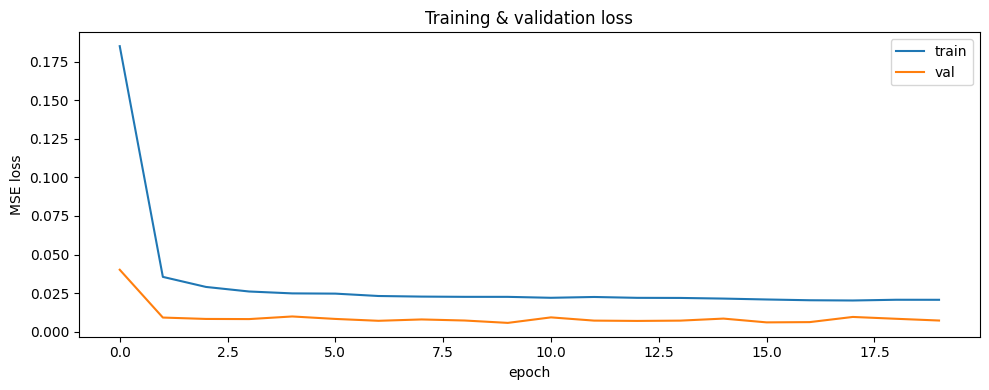

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"],   label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss"); ax.legend()
plt.title("Training & validation loss")
plt.tight_layout(); plt.show()

## 8. Evaluate on validation set

MAE reported in **original units** (°C and %) by inverting the scaler.

In [31]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())
        actuals.append(yb.numpy())

y_pred = np.concatenate(preds)    # (N, HORIZON, 2)
y_val  = np.concatenate(actuals)  # (N, HORIZON, 2)

# Invert scaling for the two target columns only
tgt_idx     = [FEATURES.index(t) for t in TARGETS]
target_mean = scaler.mean_[tgt_idx]
target_std  = scaler.scale_[tgt_idx]

y_pred_real = y_pred * target_std + target_mean
y_val_real  = y_val  * target_std + target_mean

# Clip physically impossible humidity values
hum_idx = TARGETS.index("humidity")
y_pred_real[:, :, hum_idx] = np.clip(y_pred_real[:, :, hum_idx], 0, 100)

for i, name in enumerate(TARGETS):
    mae = mean_absolute_error(y_val_real[:, :, i].ravel(),
                              y_pred_real[:, :, i].ravel())
    print(f"MAE {name:12s}: {mae:.3f}")

MAE temperature : 0.275
MAE humidity    : 0.966


## 9. Visual check — first 5 validation samples

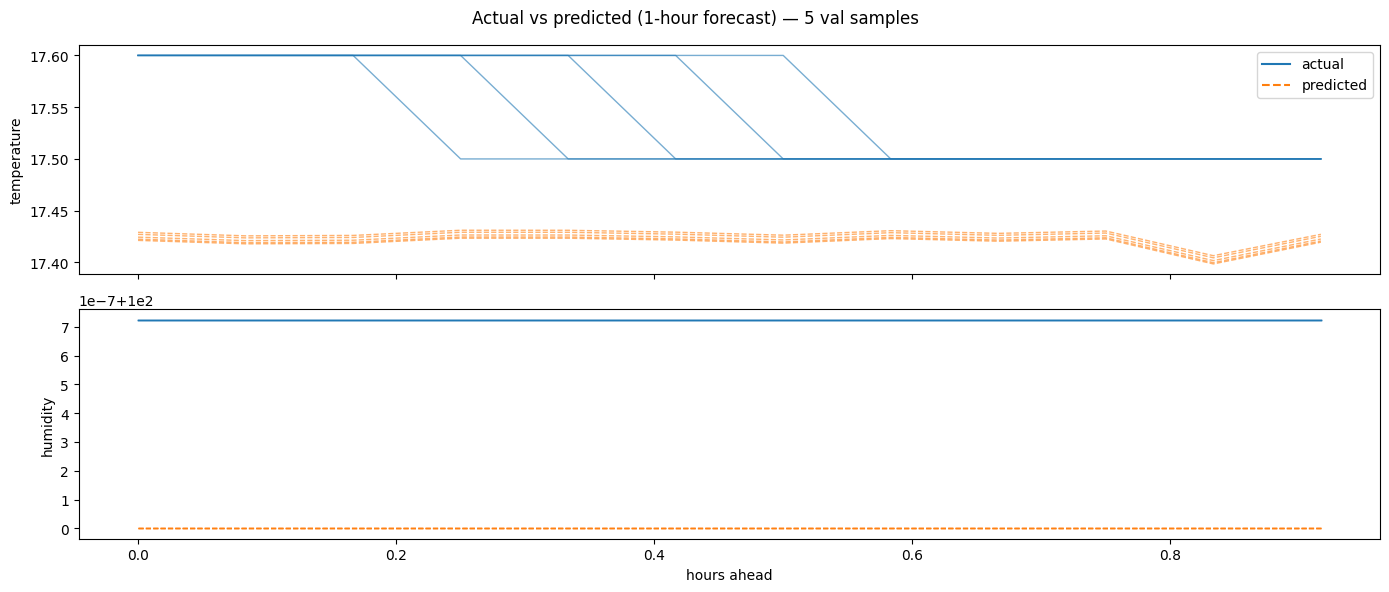

In [32]:
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(14, 6), sharex=True)
steps = np.arange(HORIZON) * 5 / 60  # hours ahead

for i, (ax, name) in enumerate(zip(axes, TARGETS)):
    for s in range(5):
        ax.plot(steps, y_val_real[s, :, i],  "C0-",  alpha=0.6, linewidth=1)
        ax.plot(steps, y_pred_real[s, :, i], "C1--", alpha=0.6, linewidth=1)
    ax.set_ylabel(name)
axes[0].plot([], [], "C0-",  label="actual")
axes[0].plot([], [], "C1--", label="predicted")
axes[0].legend()
axes[-1].set_xlabel("hours ahead")
plt.suptitle("Actual vs predicted (1-hour forecast) — 5 val samples")
plt.tight_layout(); plt.show()

## 10. Save model & scaler

In [33]:
torch.save(model.state_dict(), "models/weather_lstm.pt")
joblib.dump(scaler, "models/scaler.pkl")
print("Saved: models/weather_lstm.pt")
print("Saved: models/scaler.pkl")

Saved: weather_lstm.pt
Saved: scaler.pkl
